In [3]:
import numpy as np
import matplotlib.pyplot as plt
from memory_profiler import memory_usage
import time

Optimized point: [0.45753106 0.45981585]
Final Cost: 0.4207652886115243


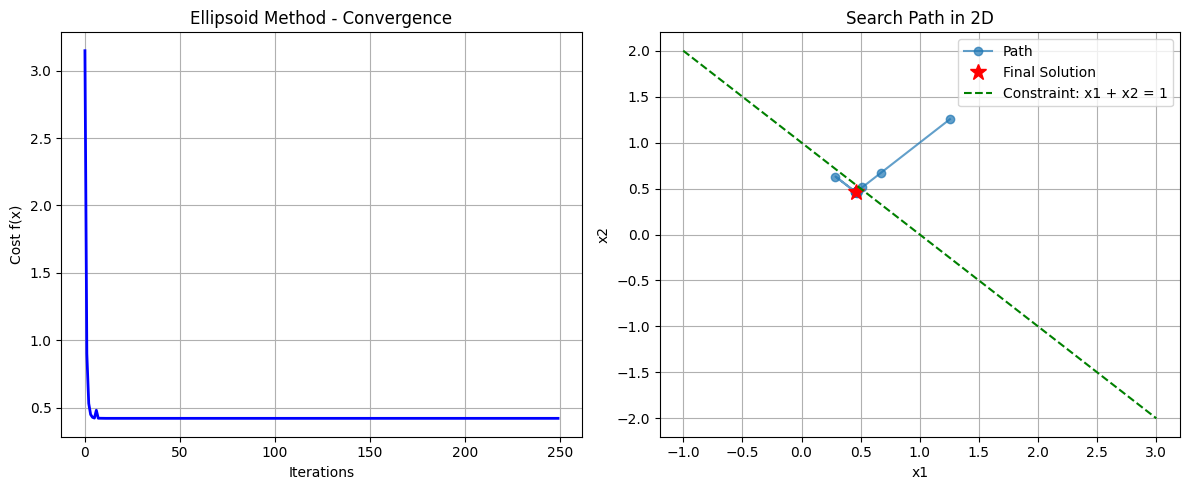

In [27]:
def objective(x):
    return np.sum(x**2)
def constraint(x):
    return (np.linalg.norm(x))<=5
def oracle(x):
    if not constraint(x):
        x = np.array([1 ,1])
    return 2*x
def ellipsoid_step(c, h, w):
    n = len(c)
    w = w/(np.linalg.norm(w))
    Hw = h @ w
    denominator = np.sqrt(w.T @ h @ w)
    c_new =  c - ((1/(n+1))*(Hw/(denominator+ 1e-16)))
    factor = n**2 / (n**2 + 1)
    term = (2/(n+1)) * np.outer(Hw, Hw) / ((w.T @ h @ w) + 1e-16)
    h_new = factor * (h - term)
    return c_new, h_new
def ellipsoid_optimization(T = 5000):
    n = 2
    c = np.array([2, 2])
    h = np.eye(n)*10
    cost = []
    history = []
    for t in range(T):
        w = oracle(c)
        c, h = ellipsoid_step(c, h, w)
        if t%2==0:
            history.append(c.copy())
            cost.append(objective(c))
    return c, np.array(history), np.array(cost)
final_c, path, cost_history = ellipsoid_optimization(T =500)

print("Optimized point:", final_c)
print("Final Cost:", objective(final_c))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cost_history, 'b-', linewidth=2)
plt.xlabel("Iterations")
plt.ylabel("Cost f(x)")
plt.title("Ellipsoid Method - Convergence")
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(path[:, 0], path[:, 1], 'o-', alpha=0.7, label="Path")
plt.plot(final_c[0], final_c[1], 'r*', markersize=12, label="Final Solution")
x_line = np.linspace(-1, 3, 100)
plt.plot(x_line, 1 - x_line, 'g--', label="Constraint: x1 + x2 = 1")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Search Path in 2D")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()